# 03 - Contraste, seuillage et contours

## Objectif

Mettre en évidence les zones suspectes avec le contraste, le seuillage et la détection de contours.

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

import cv2
import matplotlib.pyplot as plt

from src.filtering import apply_clahe, gaussian_blur
from src.preprocessing import read_grayscale_image, resize_image
from src.segmentation import adaptive_threshold, canny_edges, find_external_contours, otsu_threshold
from src.utils import build_image_index, display_images

## 1. Image de travail

On applique le même prétraitement que précédemment pour garder une logique cohérente.

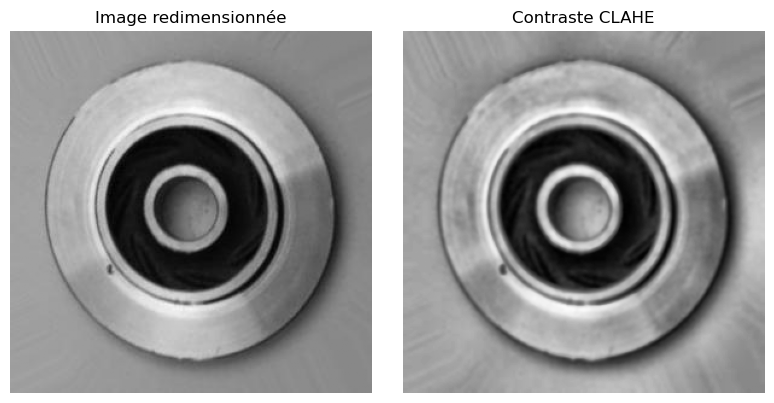

In [6]:
index_df = build_image_index()
if index_df.empty:
    raise FileNotFoundError("Aucune image trouvée dans data/raw/casting_data/.")

candidate = index_df[(index_df["split"] == "train") & (index_df["label_name"] == "Defective")]
sample_row = candidate.iloc[0] if not candidate.empty else index_df.iloc[0]

image = read_grayscale_image(sample_row["path"])
resized = resize_image(image, size=(300, 300))
blurred = gaussian_blur(resized)
enhanced = apply_clahe(blurred)

display_images([resized, enhanced], titles=["Image redimensionnée", "Contraste CLAHE"], cols=2, figsize=(8, 4))

## 2. Seuillage

Le seuillage transforme l'image en masque binaire. Ici, le seuillage inverse aide à isoler les régions sombres.

Seuil Otsu : 104.00


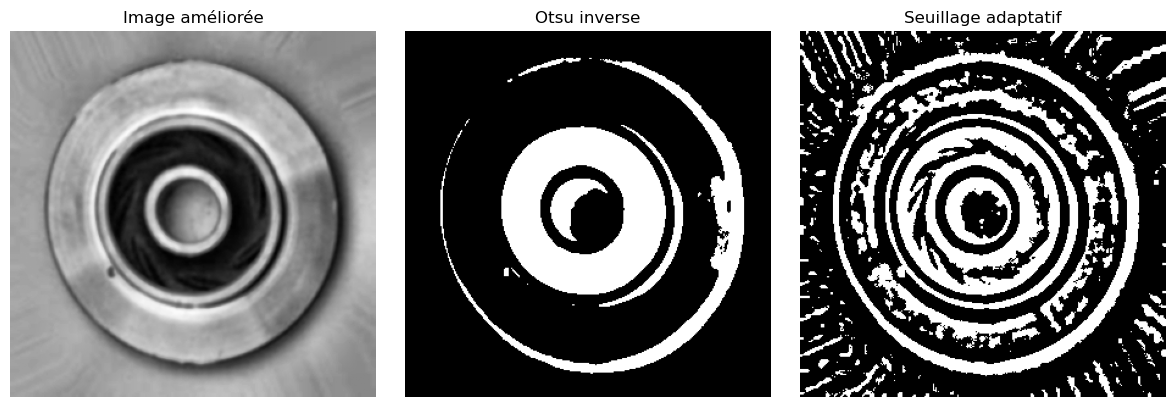

In [7]:
otsu_value, otsu_mask = otsu_threshold(enhanced, invert=True)
adaptive_mask = adaptive_threshold(enhanced, block_size=31, c=3, invert=True)

print(f"Seuil Otsu : {otsu_value:.2f}")
display_images(
    [enhanced, otsu_mask, adaptive_mask],
    titles=["Image améliorée", "Otsu inverse", "Seuillage adaptatif"],
    cols=3,
    figsize=(12, 4),
)

### Interprétation
Dans cette étape, nous avons appliqué le seuillage pour transformer l’image améliorée en image binaire et mieux séparer les zones importantes du reste. Le seuillage d’Otsu inverse donne ici un résultat plus propre et plus simple à exploiter, car il met bien en évidence les grandes structures de la pièce tout en limitant le bruit. En revanche, le seuillage adaptatif fait ressortir plus de détails locaux, mais il génère aussi beaucoup de petites régions parasites, surtout dans le fond et autour de la pièce. Dans ce cas, le seuillage d’Otsu inverse semble donc plus adapté pour la suite de l’analyse.

## 3. Détection de contours

Les contours permettent de visualiser les frontières des zones détectées.

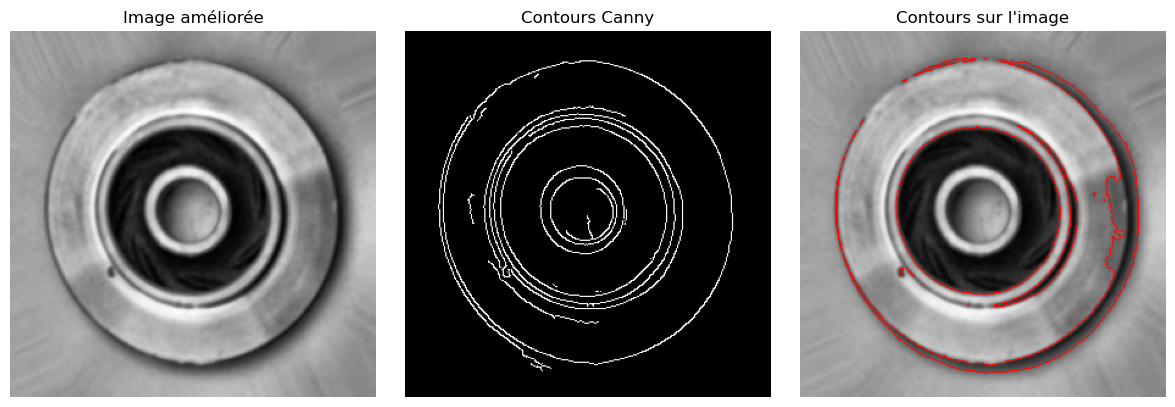

In [8]:
edges = canny_edges(enhanced)
contours = find_external_contours(otsu_mask)

contour_view = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_view, contours, -1, (255, 0, 0), 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(enhanced, cmap="gray")
plt.title("Image améliorée")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap="gray")
plt.title("Contours Canny")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(contour_view)
plt.title("Contours sur l'image")
plt.axis("off")
plt.tight_layout()
plt.show()

### Interprétation
Après le seuillage, nous avons utilisé la détection de contours pour repérer les limites principales de la pièce. La méthode de Canny permet de bien visualiser les bords circulaires extérieurs et intérieurs, ainsi que certaines petites irrégularités. Ensuite, le tracé des contours directement sur l’image rend le résultat plus clair et plus facile à interpréter, car on voit exactement où se trouvent les régions détectées. Cette étape est importante, car elle permet de localiser les structures utiles de la pièce et de préparer les mesures nécessaires pour la suite du projet.

## Conclusion

Le seuillage donne une première segmentation. Il faut ensuite nettoyer le masque pour obtenir des mesures plus fiables.